In [1]:
import numpy as np
import pandas as pd

# Reproducible randomness - same "random" data every time we run this
np.random.seed(42)

n_days = 75  # about 2.5 months of data

# --- Simulate daily habits ---
caffeine_cups = np.random.poisson(lam=1.5, size=n_days)
caffeine_cups = np.clip(caffeine_cups, 0, 5)

screen_time_minutes = np.random.normal(loc=45, scale=25, size=n_days)
screen_time_minutes = np.clip(screen_time_minutes, 0, 120).round(0)

# --- Simulate sleep outcomes, with built-in realistic effects ---
base_sleep = 7.5
sleep_hours = (
    base_sleep
    - 0.15 * caffeine_cups
    - 0.01 * screen_time_minutes
    + np.random.normal(0, 0.5, n_days)
)
sleep_hours = np.clip(sleep_hours, 3, 10).round(2)

awakening_rate = 0.5 + 0.25 * caffeine_cups + 0.015 * screen_time_minutes
awakenings = np.random.poisson(lam=np.clip(awakening_rate, 0.1, None))

df = pd.DataFrame({
    "day": np.arange(1, n_days + 1),
    "caffeine_cups": caffeine_cups,
    "screen_time_minutes": screen_time_minutes,
    "sleep_hours": sleep_hours,
    "awakenings": awakenings,
})

# Simulate a few realistic messy rows (this is what "cleaning" will fix)
df.loc[5, "sleep_hours"] = np.nan
df.loc[30, "screen_time_minutes"] = -10
df = pd.concat([df, df.iloc[[10]]], ignore_index=True)

df.to_csv("sleep_data_raw.csv", index=False)
print("Saved sleep_data_raw.csv with", len(df), "rows")
print(df.head(10))

Saved sleep_data_raw.csv with 76 rows
   day  caffeine_cups  screen_time_minutes  sleep_hours  awakenings
0    1              3                 65.0         6.73           3
1    2              0                 14.0         7.20           0
2    3              0                 51.0         7.37           0
3    4              0                 78.0         6.33           0
4    5              3                  5.0         6.88           1
5    6              2                 50.0          NaN           2
6    7              0                 51.0         7.03           1
7    8              0                 65.0         8.01           0
8    9              1                 14.0         6.28           3
9   10              1                 12.0         7.57           1


In [2]:
import pandas as pd

df = pd.read_csv("sleep_data_raw.csv")
print("Before cleaning:", df.shape)

df = df.drop_duplicates()
df = df[df["screen_time_minutes"] >= 0]
df["sleep_hours"] = df["sleep_hours"].fillna(df["sleep_hours"].median())

assert df.isnull().sum().sum() == 0, "There are still missing values!"
assert (df["screen_time_minutes"] >= 0).all(), "Negative screen time still present!"

print("After cleaning:", df.shape)
df.to_csv("sleep_data_clean.csv", index=False)
print("Saved sleep_data_clean.csv")
print(df.describe())

Before cleaning: (76, 5)
After cleaning: (74, 5)
Saved sleep_data_clean.csv
             day  caffeine_cups  screen_time_minutes  sleep_hours  awakenings
count  74.000000      74.000000            74.000000    74.000000   74.000000
mean   38.094595       1.405405            48.837838     6.772838    1.783784
std    21.927757       1.270518            23.827593     0.566524    1.377612
min     1.000000       0.000000             5.000000     4.850000    0.000000
25%    19.250000       0.000000            26.250000     6.505000    1.000000
50%    38.500000       1.000000            52.000000     6.780000    2.000000
75%    56.750000       2.000000            62.500000     7.117500    3.000000
max    75.000000       5.000000           120.000000     8.010000    5.000000


Correlation matrix:
                     caffeine_cups  screen_time_minutes  sleep_hours  \
caffeine_cups                 1.00                -0.11        -0.31   
screen_time_minutes          -0.11                 1.00        -0.14   
sleep_hours                  -0.31                -0.14         1.00   
awakenings                    0.11                 0.01         0.01   

                     awakenings  
caffeine_cups              0.11  
screen_time_minutes        0.01  
sleep_hours                0.01  
awakenings                 1.00  

Caffeine vs Sleep Hours
  Low group mean:  6.90  (n=42)
  High group mean: 6.61  (n=32)
  t-statistic: 2.267   p-value: 0.0264
  -> Significant (p < 0.05)

Caffeine vs Awakenings
  Low group mean:  1.64  (n=42)
  High group mean: 1.97  (n=32)
  t-statistic: -1.029   p-value: 0.3069
  -> Not significant (p >= 0.05)

Screen Time vs Sleep Hours
  Low group mean:  6.83  (n=39)
  High group mean: 6.71  (n=35)
  t-statistic: 0.910   p-value: 0.3663
 

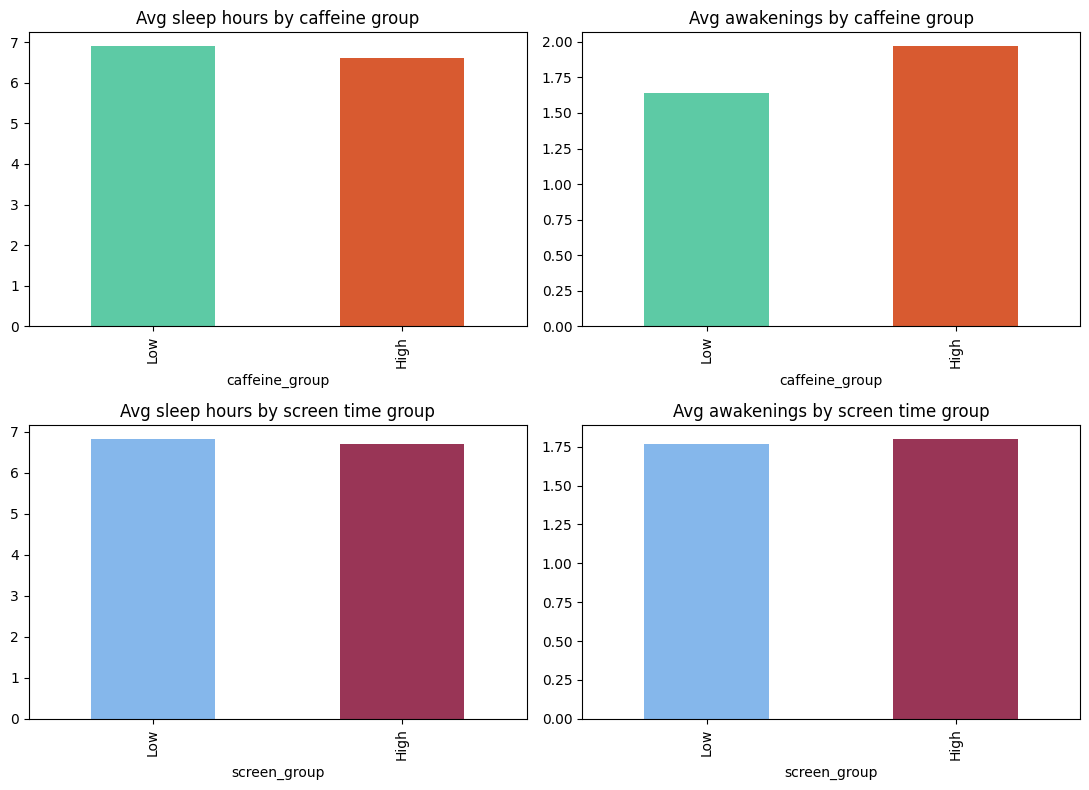

Saved sleep_analysis_charts.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("sleep_data_clean.csv")

caffeine_median = df["caffeine_cups"].median()
screen_median = df["screen_time_minutes"].median()

df["caffeine_group"] = df["caffeine_cups"].apply(lambda x: "High" if x > caffeine_median else "Low")
df["screen_group"] = df["screen_time_minutes"].apply(lambda x: "High" if x > screen_median else "Low")

print("Correlation matrix:")
print(df[["caffeine_cups", "screen_time_minutes", "sleep_hours", "awakenings"]].corr().round(2))

def run_ttest(df, group_col, outcome_col, label):
    low = df[df[group_col] == "Low"][outcome_col]
    high = df[df[group_col] == "High"][outcome_col]
    t_stat, p_val = stats.ttest_ind(low, high, equal_var=False)
    print(f"\n{label}")
    print(f"  Low group mean:  {low.mean():.2f}  (n={len(low)})")
    print(f"  High group mean: {high.mean():.2f}  (n={len(high)})")
    print(f"  t-statistic: {t_stat:.3f}   p-value: {p_val:.4f}")
    print("  -> Significant (p < 0.05)" if p_val < 0.05 else "  -> Not significant (p >= 0.05)")

run_ttest(df, "caffeine_group", "sleep_hours", "Caffeine vs Sleep Hours")
run_ttest(df, "caffeine_group", "awakenings", "Caffeine vs Awakenings")
run_ttest(df, "screen_group", "sleep_hours", "Screen Time vs Sleep Hours")
run_ttest(df, "screen_group", "awakenings", "Screen Time vs Awakenings")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
df.groupby("caffeine_group")["sleep_hours"].mean().reindex(["Low", "High"]).plot(kind="bar", ax=axes[0,0], color=["#5DCAA5","#D85A30"], title="Avg sleep hours by caffeine group")
df.groupby("caffeine_group")["awakenings"].mean().reindex(["Low", "High"]).plot(kind="bar", ax=axes[0,1], color=["#5DCAA5","#D85A30"], title="Avg awakenings by caffeine group")
df.groupby("screen_group")["sleep_hours"].mean().reindex(["Low", "High"]).plot(kind="bar", ax=axes[1,0], color=["#85B7EB","#993556"], title="Avg sleep hours by screen time group")
df.groupby("screen_group")["awakenings"].mean().reindex(["Low", "High"]).plot(kind="bar", ax=axes[1,1], color=["#85B7EB","#993556"], title="Avg awakenings by screen time group")
plt.tight_layout()
plt.savefig("sleep_analysis_charts.png", dpi=150)
plt.show()
print("Saved sleep_analysis_charts.png")